In [1]:
# Task 1: Acquire Peru’s protected-area polygons from OSM
import osmnx as ox
import geopandas as gpd

# 1. Obtener la geometría de Perú
peru = ox.geocode_to_gdf("Peru")

# 2. Definir los tags que se quiere extraer de OSM
tags = {
    "boundary": "protected_area",
    "leisure": "nature_reserve",
    "protect_class": True  # Cualquier valor
}

In [2]:
# 3. Descargar los objetos OSM dentro del polígono de Perú con esos tags
print("Iniciando descarga...")
gdf = ox.features_from_polygon(peru.geometry[0], tags)
print("Descarga terminada")

Iniciando descarga...


C:\Users\sebas\anaconda3\envs\HW4\lib\site-packages\osmnx\_overpass.py:267: UserWarning: This area is 1,086 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


Descarga terminada


In [5]:
# 4. Filtrar solo los objetos que sean parques, reservas, bosques protegidos
# Aquí se especifica explícitamente las clases de protección que se aceptan
clases_aceptadas = ["2", "4", "6"]
gdf_filtrado = gdf[gdf["protect_class"].isin(clases_aceptadas)]

# 5. Guardar el resultado en un GeoPackage
gdf_filtrado.to_file("peru_protected_areas.gpkg", driver="GPKG")

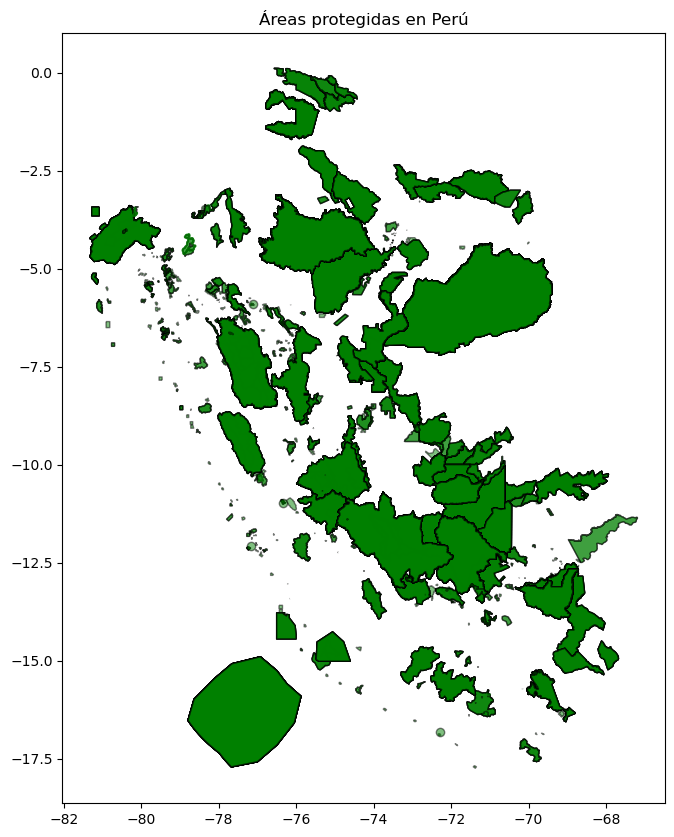

In [7]:
# 6. Mostrar grafico con matplotlib
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,10))
gdf.plot(ax=ax, color='green', edgecolor='black', alpha=0.5)
plt.title("Áreas protegidas en Perú")
plt.show()

In [9]:
# Task 2: Download VCF (MOD44B v061) for 2024
import os
import requests
import rioxarray
import xarray as xr
from rasterio.merge import merge
from rasterio.io import MemoryFile
import rasterio
from getpass import getpass

In [ ]:
# 1. URLs de los tiles MOD44B del año 2024
urls = [
    "https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/MOD44B.061/MOD44B.A2023065.h10v10.061.2024128174658/MOD44B.A2023065.h10v10.061.2024128174658.hdf",
    "https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/MOD44B.061/MOD44B.A2023065.h10v09.061.2024128174145/MOD44B.A2023065.h10v09.061.2024128174145.hdf",
    "https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/MOD44B.061/MOD44B.A2023065.h11v10.061.2024128174320/MOD44B.A2023065.h11v10.061.2024128174320.hdf",
    "https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/MOD44B.061/MOD44B.A2023065.h09v09.061.2024128174108/MOD44B.A2023065.h09v09.061.2024128174108.hdf",
]

# 2. Directorio local para guardar los archivos
os.makedirs("mod44b_tiles", exist_ok=True)

# 3. Credenciales de Earthdata Login (debes registrarte en https://urs.earthdata.nasa.gov)
username = input("Earthdata username: ")
password = getpass("Earthdata password: ")

# Sesión con autenticación
session = requests.Session()
session.auth = (username, password)

# Headers requeridos por Earthdata
session.headers.update({
    "User-Agent": "earthdata-downloader/1.0",
    "Accept": "*/*"
})

# 4. Descargar archivos
hdf_files = []
for url in urls:
    filename = os.path.join("mod44b_tiles", url.split("/")[-1])
    hdf_files.append(filename)

    if not os.path.exists(filename):
        print(f"Descargando {filename}...")
        response = requests.get(url, auth=(username, password))
        if response.status_code == 200:
            with open(filename, "wb") as f:
                f.write(response.content)
        else:
            print(f"Error al descargar {filename}: {response.status_code}")
    else:
        print(f"{filename} ya existe.")

In [11]:
# Ruta a tu carpeta local con archivos HDF descargados
path_to_hdf_folder = r"C:/Users/sebas/Documents/mod44b_tiles"

# Lista de archivos HDF en esa carpeta
hdf_files = [
    os.path.join(path_to_hdf_folder, f)
    for f in os.listdir(path_to_hdf_folder)
    if f.endswith(".hdf")
]

# Mostrar los archivos encontrados (opcional)
print(f"{len(hdf_files)} archivos encontrados:")
for f in hdf_files:
    print(f)

4 archivos encontrados:
C:/Users/sebas/Documents/mod44b_tiles\MOD44B.A2024065.h09v09.061.2025133154709.hdf
C:/Users/sebas/Documents/mod44b_tiles\MOD44B.A2024065.h10v09.061.2025133155323.hdf
C:/Users/sebas/Documents/mod44b_tiles\MOD44B.A2024065.h10v10.061.2025133155101.hdf
C:/Users/sebas/Documents/mod44b_tiles\MOD44B.A2024065.h11v10.061.2025133155233.hdf


In [15]:
# 5. Extraer la capa Percent_Tree_Cover
datasets = []
for file in hdf_files:
    print(f"Procesando: {file}")
    
    # Ruta del subdataset de cobertura arbórea
    subdataset_path = f'HDF4_EOS:EOS_GRID:"{file}":MOD44B_250m_GRID:Percent_Tree_Cover'
    
    # Abrir el subdataset
    ds = rioxarray.open_rasterio(subdataset_path, masked=True)
    
    # Asignar CRS si no tiene
    ds.rio.write_crs("EPSG:4326", inplace=True)
    
    # Añadir a la lista
    datasets.append(ds)
    
# Lista de dimensiones
print(ds.dims)

Procesando: C:/Users/sebas/Documents/mod44b_tiles\MOD44B.A2024065.h09v09.061.2025133154709.hdf
Procesando: C:/Users/sebas/Documents/mod44b_tiles\MOD44B.A2024065.h10v09.061.2025133155323.hdf
Procesando: C:/Users/sebas/Documents/mod44b_tiles\MOD44B.A2024065.h10v10.061.2025133155101.hdf
Procesando: C:/Users/sebas/Documents/mod44b_tiles\MOD44B.A2024065.h11v10.061.2025133155233.hdf
('band', 'y', 'x')


In [17]:
# 6. Unir (mosaicar) todos los tiles
print("Mosaicando tiles...")
merged = xr.concat(datasets, dim="band").mean("band")

# 7. Reproyectar a EPSG:4326
print("Reproyectando...")
merged = merged.rio.reproject("EPSG:4326")

# 8. Guardar como GeoTIFF
output_path = "vcf_2024_peru.tif"
print(f"Guardando en {output_path}...")
merged.rio.to_raster(output_path)

print("✅ Listo.")

Mosaicando tiles...
Reproyectando...
Guardando en vcf_2024_peru.tif...
✅ Listo.


<xarray.DataArray (band: 1, y: 9600, x: 14400)> Size: 553MB
[138240000 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 115kB -1.001e+07 -1.001e+07 ... -6.672e+06
  * y            (y) float64 77kB -347.5 -579.1 -810.7 ... -2.223e+06 -2.224e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    _FillValue:     nan
    scale_factor:   1.0
    add_offset:     0.0


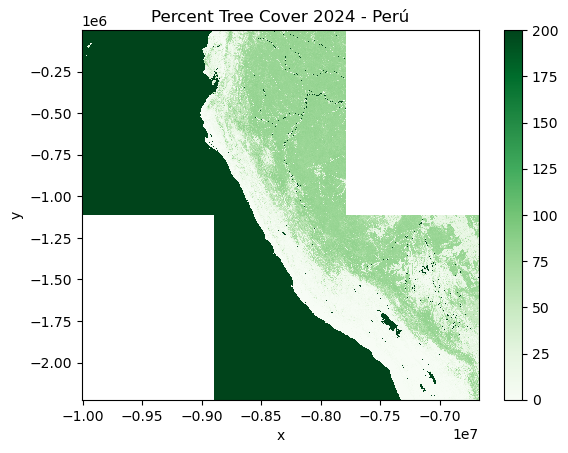

In [23]:
import matplotlib.pyplot as plt
import rioxarray

raster = rioxarray.open_rasterio("vcf_2024_peru.tif")
print(raster)
raster.squeeze().plot(cmap="Greens")
plt.title("Percent Tree Cover 2024 - Perú")
plt.show()

In [53]:
#Task 3
import geopandas as gpd

# Carga la capa desde el geopackage
gdf_parks = gpd.read_file("peru_protected_areas.gpkg")  # Ajusta el nombre si es distinto

# Asegúrate de que esté en el CRS adecuado (EPSG:4326 para coincidir con el raster)
gdf_parks = gdf_parks.to_crs("EPSG:4326")

In [45]:
from shapely.geometry import Polygon
import pandas as pd

def zonal_stats_from_geom(geom, raster):
    try:
        out_image, out_transform = mask(raster, [geom], crop=True)
        data = out_image[0]
        data = data[data != raster.nodata]
        if len(data) == 0:
            return None
        return {
            "mean_tc": np.mean(data),
            "median_tc": np.median(data),
            "sd_tc": np.std(data),
            "n_pixels": len(data)
        }
    except:
        return None

results = []

In [ ]:
# Bandas de buffer
buffers_km = [5, 10, 20, 25]

# Iterar sobre cada área protegida
for idx, row in gdf.iterrows(): 
    park_id = idx
    geom = row["geometry"]
    
    for b in buffers_km:
        # Crear inner y outer buffer
        outer = geom.buffer(b * 1000)
        inner = geom.buffer(-b * 1000)

        # Outer ring: anillo externo sin la parte interior
        outer_ring = outer.difference(geom)
        # Inner ring: anillo interno sin el centro
        inner_ring = geom.difference(inner)

        for ring_geom, in_out in [(inner_ring, "in"), (outer_ring, "out")]:
            stats = zonal_stats_from_geom(ring_geom, raster)
            if stats:
                results.append({
                    "park_id": park_id,
                    "buffer_km": b,
                    "in_out": in_out,
                    **stats
                })

print(f"Agregado stats para parque {park_id}, buffer {b}km, {in_out}")

In [55]:
import pandas as pd

# Convertir lista de dicts a DataFrame
df = pd.DataFrame(results)

# Renombrar columnas según lo que pide el enunciado
df = df.rename(columns={
    "mean": "mean_tc",
    "median": "median_tc",
    "std": "sd_tc",
    "count": "Percent_Tree_Cover"  # Esto representa el número de píxeles
})

# Guardar a CSV
df.to_csv("forest_cover_buffers.csv", index=False)
print("✅ CSV guardado como forest_cover_buffers.csv")

✅ CSV guardado como forest_cover_buffers.csv
